# RQ3a — Chain-of-Thought Intervention
Compares CoT accuracy against RQ1 baseline. Does step-by-step reasoning help resist peer pressure?

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

RQ3A_DIR = Path("../results_todos/rq3a")
RQ1_DIR  = Path("../results_todos/rq1")

RQ1_CONDITIONS = [
    "all_correct_absent", "all_correct_present",
    "mixed_absent",       "mixed_present",
    "all_wrong_absent",   "all_wrong_present",
]
CONDITION_LABELS = {
    "all_correct_absent":  "All-correct\n(no auth)",
    "all_correct_present": "All-correct\n(auth)",
    "mixed_absent":        "Mixed\n(no auth)",
    "mixed_present":       "Mixed\n(auth)",
    "all_wrong_absent":    "All-wrong\n(no auth)",
    "all_wrong_present":   "All-wrong\n(auth)",
}

def dataset_of(csv_path):
    """Classify a metrics CSV as in-distribution (primevul) or out-of-distribution (ood_benchmark)."""
    name = csv_path.name
    if "ood_benchmark" in name:
        return "ood"
    if "primevul" in name:
        return "id"
    return None

def load_combined(results_dir):
    """Returns (id_df, ood_df) grouped/averaged over seeds, split by dataset."""
    id_dfs, ood_dfs = [], []
    for csv_path in sorted(results_dir.rglob("*.metrics.csv")):
        if "primevul_dataset" in csv_path.name or "_all_seeds" in csv_path.name:
            continue
        parts = csv_path.parts
        if not any(p.startswith("seed_") for p in parts):
            continue
        dataset = dataset_of(csv_path)
        if dataset is None:
            continue
        df = pd.read_csv(csv_path)
        df = df[df["condition"].isin(RQ1_CONDITIONS + ["ALL"])]
        if df.empty:
            continue
        (id_dfs if dataset == "id" else ood_dfs).append(df)

    def group(dfs):
        all_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
        return all_df.groupby(["model", "condition"]).mean(numeric_only=True).reset_index() if not all_df.empty else pd.DataFrame()

    return group(id_dfs), group(ood_dfs)

cot, cot_ood = load_combined(RQ3A_DIR)
rq1, rq1_ood = load_combined(RQ1_DIR)

MODELS = sorted(cot["model"].unique())
PALETTE = sns.color_palette("tab10", len(MODELS))
MODEL_COLORS = dict(zip(MODELS, PALETTE))

print(f"Models: {MODELS}")
print(f"In-distribution (primevul) conditions: {sorted(cot['condition'].unique())}")
print(f"Out-of-distribution (ood_benchmark) conditions: "
      f"{sorted(cot_ood['condition'].unique()) if not cot_ood.empty else 'no OOD data found'}")


Models: ['llama31_it', 'mistral_it', 'phi35_it', 'qwen25_it']
In-distribution (primevul) conditions: ['ALL', 'all_correct_absent', 'all_correct_present', 'all_wrong_absent', 'all_wrong_present', 'mixed_absent', 'mixed_present']
Out-of-distribution (ood_benchmark) conditions: ['ALL', 'all_correct_absent', 'all_correct_present', 'all_wrong_absent', 'all_wrong_present', 'mixed_absent', 'mixed_present']


## Per-model tables (CoT)

> **Note on acc_r1:** The CoT Round 1 prompt asks the model to think step-by-step before answering, which genuinely changes initial responses. The `acc_r1` here reflects CoT-prompted Round 1 accuracy — it is not the same as the standard Round 1 baseline in RQ1, even on identical instances.

In [10]:
display_cols = ["condition", "n", "acc_r1", "acc_r2", "delta_acc",
                "rev_pct", "harm_pct", "ben_pct"]

for model in MODELS:
    df_m = cot[(cot["model"] == model) & (cot["condition"].isin(RQ1_CONDITIONS))].copy()
    present = [c for c in RQ1_CONDITIONS if c in df_m["condition"].values]
    df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
    df_m = df_m.sort_values("condition")[display_cols].reset_index(drop=True)
    print(f"\n{'─'*60}\n  {model.upper()} — CoT\n{'─'*60}")
    display(df_m.style
        .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                 **{c: "{:.1f}" for c in ["acc_r1","acc_r2","delta_acc","rev_pct","harm_pct","ben_pct"]}}, na_rep="N/A")
        .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
        .background_gradient(subset=["harm_pct"],  cmap="Reds",   vmin=0,   vmax=100)
        .background_gradient(subset=["ben_pct"],   cmap="Greens", vmin=0,   vmax=100)
        .set_caption(f"{model} CoT"))



────────────────────────────────────────────────────────────
  LLAMA31_IT — CoT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct
0,all_correct_absent,499.33,49.2,46.1,-3.1,67.4,71.6,63.3
1,all_correct_present,499.33,49.2,46.3,-2.9,67.8,71.8,63.9
2,mixed_absent,499.33,49.2,49.5,0.3,68.2,68.9,67.4
3,mixed_present,499.33,49.2,49.7,0.5,71.2,71.9,70.6
4,all_wrong_absent,499.33,49.2,57.3,8.1,69.8,62.7,76.7
5,all_wrong_present,499.33,49.2,52.8,3.6,70.0,67.4,72.4



────────────────────────────────────────────────────────────
  MISTRAL_IT — CoT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct
0,all_correct_absent,499.33,59.6,57.7,-1.9,35.8,31.6,42.0
1,all_correct_present,499.33,59.6,57.8,-1.8,39.2,34.4,46.3
2,mixed_absent,499,59.6,51.8,-7.8,23.3,26.1,19.2
3,mixed_present,498.67,59.6,52.1,-7.4,28.1,29.9,25.6
4,all_wrong_absent,498.67,59.6,44.6,-15.0,35.3,42.2,25.1
5,all_wrong_present,499,59.6,41.1,-18.4,37.8,47.2,24.0



────────────────────────────────────────────────────────────
  PHI35_IT — CoT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct
0,all_correct_absent,494.33,49.2,62.2,13.0,14.5,1.5,27.1
1,all_correct_present,494.67,49.1,64.6,15.4,16.4,1.0,31.2
2,mixed_absent,494.67,49.2,51.1,1.9,8.9,7.1,10.6
3,mixed_present,494.67,49.1,51.0,1.9,11.9,10.2,13.5
4,all_wrong_absent,495.67,49.1,37.7,-11.4,12.7,24.5,1.3
5,all_wrong_present,495.33,49.1,35.7,-13.4,14.2,28.1,0.8



────────────────────────────────────────────────────────────
  QWEN25_IT — CoT
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct
0,all_correct_absent,493.67,58.3,83.4,25.1,29.5,3.8,65.5
1,all_correct_present,490.67,58.4,86.6,28.2,31.2,2.5,71.4
2,mixed_absent,490.33,58.3,59.1,0.8,24.7,20.5,30.5
3,mixed_present,489,58.5,59.3,0.8,27.4,22.7,34.0
4,all_wrong_absent,492.67,58.2,30.7,-27.5,33.8,52.7,7.6
5,all_wrong_present,493.67,58.4,24.8,-33.6,37.9,61.2,5.2


## CoT vs Base: Δ Accuracy comparison (grouped bar)

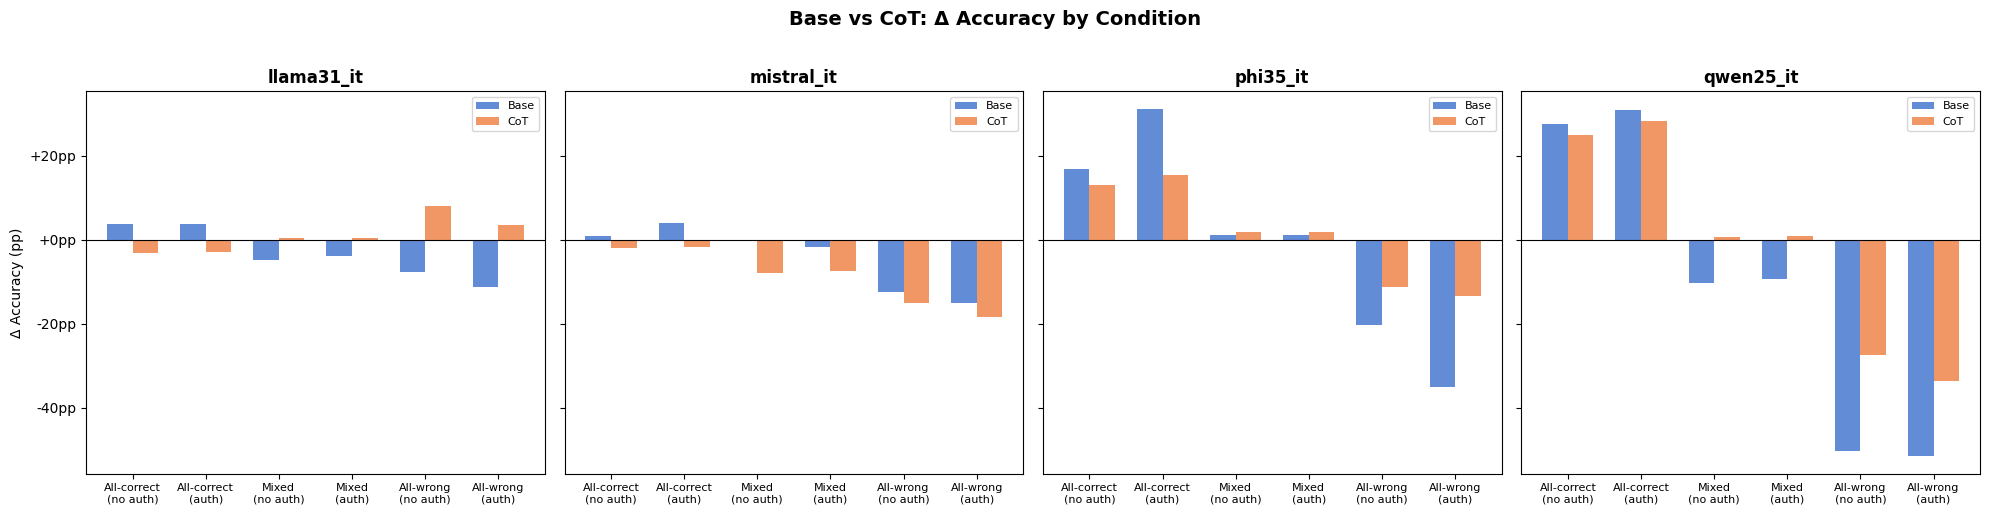

In [11]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(5*len(MODELS), 5), sharey=True)
if len(MODELS) == 1:
    axes = [axes]

for ax, model in zip(axes, MODELS):
    for df, label, color in [(rq1, "Base", "#4878d0"), (cot, "CoT", "#ee854a")]:
        df_m = df[(df["model"] == model) & (df["condition"].isin(RQ1_CONDITIONS))].copy()
        p = [c for c in RQ1_CONDITIONS if c in df_m["condition"].values]
        df_m["condition"] = pd.Categorical(df_m["condition"], categories=p, ordered=True)
        df_m = df_m.sort_values("condition")
        x = range(len(df_m))
        offset = -0.175 if label == "Base" else 0.175
        ax.bar([i + offset for i in x], df_m["delta_acc"], 0.35, label=label, color=color, alpha=0.85)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title(model, fontsize=12, fontweight="bold")
    ax.set_xticks(list(range(len(p))))
    ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in p], fontsize=8)
    ax.set_ylabel("\u0394 Accuracy (pp)" if ax == axes[0] else "")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))

plt.suptitle("Base vs CoT: \u0394 Accuracy by Condition", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(RQ3A_DIR / "rq3a_cot_vs_base.png", dpi=150, bbox_inches="tight")
plt.show()


## Δ Accuracy heatmap — CoT across models × conditions

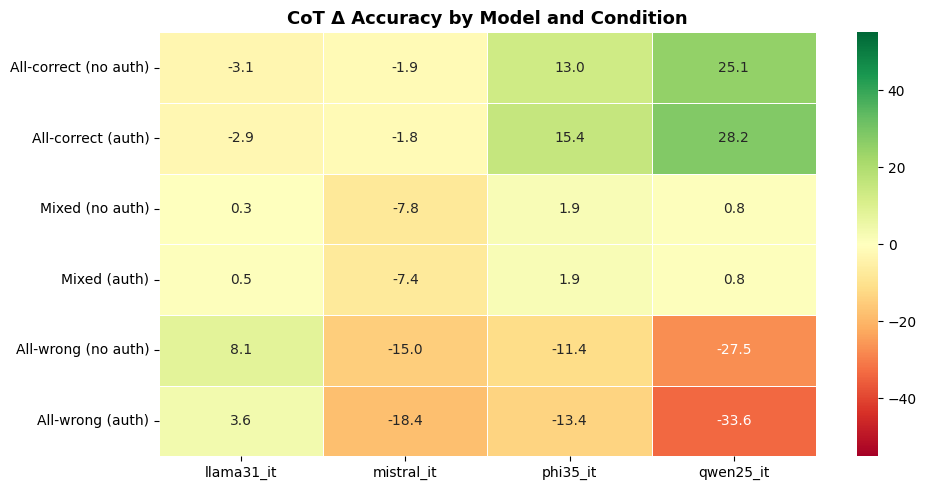

In [12]:
df_plot = cot[cot["condition"].isin(RQ1_CONDITIONS)]
pivot = df_plot.pivot_table(index="condition", columns="model", values="delta_acc")
pivot = pivot.reindex([c for c in RQ1_CONDITIONS if c in pivot.index])

fig, ax = plt.subplots(figsize=(max(6, 2.5*len(MODELS)), 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
            linewidths=0.5, ax=ax, annot_kws={"size": 10})
ax.set_title("CoT \u0394 Accuracy by Model and Condition", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_yticklabels([CONDITION_LABELS.get(c, c).replace("\n", " ") for c in pivot.index], rotation=0)
plt.tight_layout()
plt.savefig(RQ3A_DIR / "rq3a_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


# Out-of-Distribution (OOD) Results

Repeats the CoT analysis above on the `ood_benchmark_rq1_rq3` files (both for RQ3a-CoT and the RQ1 baseline), to check whether CoT's effect on peer-conformity resistance generalizes beyond the in-distribution (ID) dataset.

## Per-model tables (CoT) — OOD

In [13]:
if cot_ood.empty:
    print("No OOD data found.")
else:
    display_cols = ["condition", "n", "acc_r1", "acc_r2", "delta_acc",
                    "rev_pct", "harm_pct", "ben_pct"]

    for model in MODELS:
        df_m = cot_ood[(cot_ood["model"] == model) & (cot_ood["condition"].isin(RQ1_CONDITIONS))].copy()
        present = [c for c in RQ1_CONDITIONS if c in df_m["condition"].values]
        df_m["condition"] = pd.Categorical(df_m["condition"], categories=present, ordered=True)
        df_m = df_m.sort_values("condition")[display_cols].reset_index(drop=True)
        print(f"\n{'─'*60}\n  {model.upper()} — CoT, OOD\n{'─'*60}")
        display(df_m.style
            .format({"n": lambda x: f"{int(x)}" if pd.notna(x) and x == int(x) else (f"{x:.2f}" if pd.notna(x) else "N/A"),
                     **{c: "{:.1f}" for c in ["acc_r1","acc_r2","delta_acc","rev_pct","harm_pct","ben_pct"]}}, na_rep="N/A")
            .background_gradient(subset=["delta_acc"], cmap="RdYlGn", vmin=-30, vmax=30)
            .background_gradient(subset=["harm_pct"],  cmap="Reds",   vmin=0,   vmax=100)
            .background_gradient(subset=["ben_pct"],   cmap="Greens", vmin=0,   vmax=100)
            .set_caption(f"{model} CoT — OOD"))



────────────────────────────────────────────────────────────
  LLAMA31_IT — CoT, OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct
0,all_correct_absent,500,51.7,43.1,-8.5,67.5,73.6,61.0
1,all_correct_present,500,51.7,42.9,-8.8,68.0,74.3,61.2
2,mixed_absent,500,51.7,48.4,-3.3,67.5,68.5,66.5
3,mixed_present,500,51.7,46.7,-5.0,69.9,72.5,67.2
4,all_wrong_absent,500,51.7,53.8,2.1,66.8,62.6,71.3
5,all_wrong_present,500,51.7,53.3,1.6,66.1,62.4,70.1



────────────────────────────────────────────────────────────
  MISTRAL_IT — CoT, OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct
0,all_correct_absent,498,60.6,58.4,-2.2,31.5,27.8,37.2
1,all_correct_present,498,60.6,59.8,-0.8,35.5,29.9,44.0
2,mixed_absent,498,60.6,51.7,-8.8,22.0,25.4,16.6
3,mixed_present,498,60.6,49.8,-10.8,27.9,31.9,21.7
4,all_wrong_absent,498,60.6,42.3,-18.3,34.1,43.2,20.0
5,all_wrong_present,498,60.6,41.6,-18.9,36.9,46.1,22.7



────────────────────────────────────────────────────────────
  PHI35_IT — CoT, OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct
0,all_correct_absent,496.67,52.4,62.1,9.8,11.8,1.9,22.7
1,all_correct_present,496,52.4,65.1,12.7,13.4,0.6,27.4
2,mixed_absent,496.67,52.4,52.5,0.1,9.9,9.3,10.4
3,mixed_present,497,52.4,53.4,0.9,13.0,11.5,14.7
4,all_wrong_absent,496.67,52.4,41.0,-11.3,12.6,22.8,1.3
5,all_wrong_present,497,52.4,39.5,-12.9,13.1,24.8,0.1



────────────────────────────────────────────────────────────
  QWEN25_IT — CoT, OOD
────────────────────────────────────────────────────────────


,condition,n,acc_r1,acc_r2,delta_acc,rev_pct,harm_pct,ben_pct
0,all_correct_absent,489.67,54.3,80.2,25.9,31.0,4.6,62.2
1,all_correct_present,491,54.3,85.4,31.1,34.6,3.3,71.9
2,mixed_absent,487.67,54.2,53.6,-0.6,22.5,21.3,23.9
3,mixed_present,485.67,54.2,52.9,-1.2,25.0,24.2,25.9
4,all_wrong_absent,492.33,54.2,26.1,-28.0,31.0,54.5,3.2
5,all_wrong_present,490,54.2,20.2,-33.9,37.5,66.0,3.9


## CoT vs Base: Δ Accuracy comparison (grouped bar) — OOD

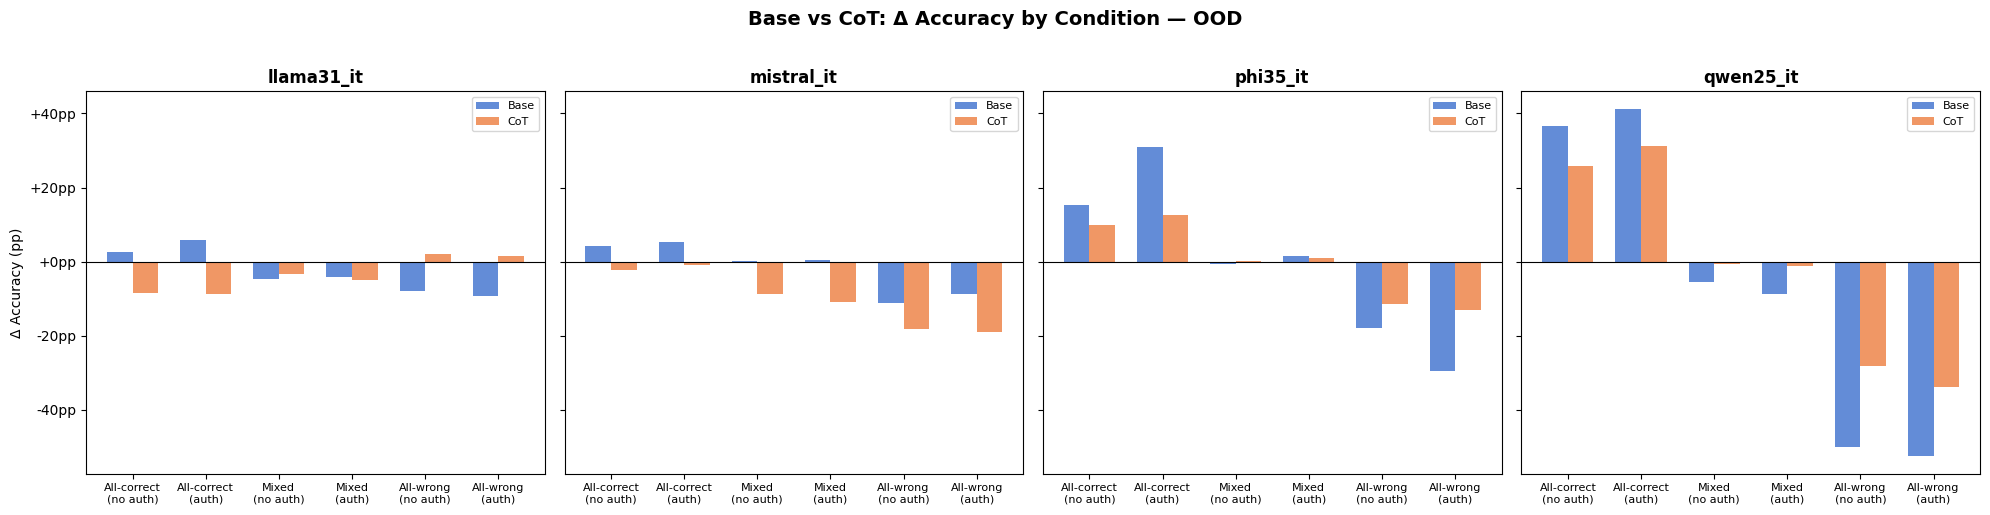

In [14]:
if cot_ood.empty or rq1_ood.empty:
    print("No OOD data found.")
else:
    fig, axes = plt.subplots(1, len(MODELS), figsize=(5*len(MODELS), 5), sharey=True)
    if len(MODELS) == 1:
        axes = [axes]

    for ax, model in zip(axes, MODELS):
        for df, label, color in [(rq1_ood, "Base", "#4878d0"), (cot_ood, "CoT", "#ee854a")]:
            df_m = df[(df["model"] == model) & (df["condition"].isin(RQ1_CONDITIONS))].copy()
            p = [c for c in RQ1_CONDITIONS if c in df_m["condition"].values]
            df_m["condition"] = pd.Categorical(df_m["condition"], categories=p, ordered=True)
            df_m = df_m.sort_values("condition")
            x = range(len(df_m))
            offset = -0.175 if label == "Base" else 0.175
            ax.bar([i + offset for i in x], df_m["delta_acc"], 0.35, label=label, color=color, alpha=0.85)
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(model, fontsize=12, fontweight="bold")
        ax.set_xticks(list(range(len(RQ1_CONDITIONS))))
        ax.set_xticklabels([CONDITION_LABELS.get(c, c) for c in RQ1_CONDITIONS], fontsize=8)
        ax.set_ylabel("Δ Accuracy (pp)" if ax == axes[0] else "")
        ax.legend(fontsize=8)
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:+.0f}pp"))

    plt.suptitle("Base vs CoT: Δ Accuracy by Condition — OOD", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(RQ3A_DIR / "rq3a_ood_cot_vs_base.png", dpi=150, bbox_inches="tight")
    plt.show()


## Δ Accuracy heatmap — CoT across models × conditions — OOD

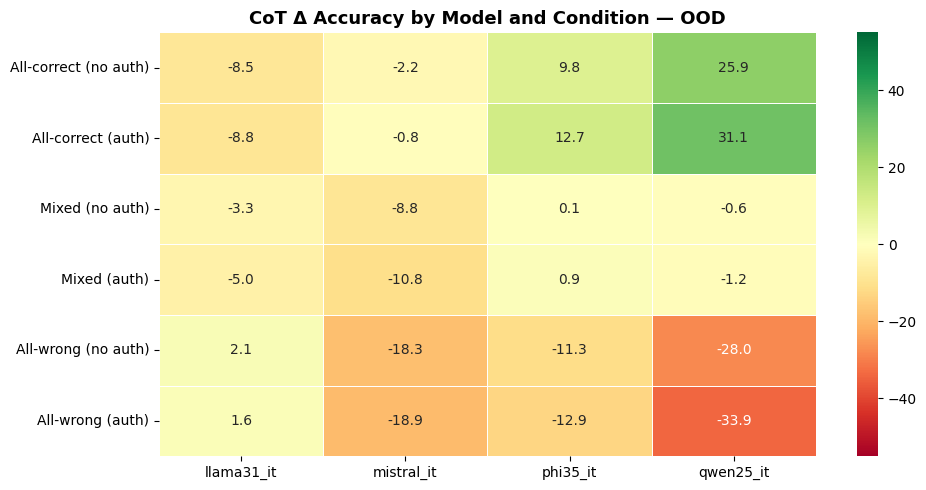

In [15]:
if cot_ood.empty:
    print("No OOD data found.")
else:
    df_plot = cot_ood[cot_ood["condition"].isin(RQ1_CONDITIONS)]
    pivot = df_plot.pivot_table(index="condition", columns="model", values="delta_acc")
    pivot = pivot.reindex([c for c in RQ1_CONDITIONS if c in pivot.index])

    fig, ax = plt.subplots(figsize=(max(6, 2.5*len(MODELS)), 5))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn", center=0, vmin=-55, vmax=55,
                linewidths=0.5, ax=ax, annot_kws={"size": 10})
    ax.set_title("CoT Δ Accuracy by Model and Condition — OOD", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_yticklabels([CONDITION_LABELS.get(c, c).replace("\n", " ") for c in pivot.index], rotation=0)
    plt.tight_layout()
    plt.savefig(RQ3A_DIR / "rq3a_ood_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
